In [9]:
import torch
from torch import nn
import torchvision
from torchvision import transforms

torch.cuda.is_available()

True

In [10]:
# load mnist dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = torchvision.datasets.MNIST( root='./data', 
                                            train=True, 
                                            transform=transform,
                                            download=True)
test_dataset = torchvision.datasets.MNIST( root='./data', 
                                           train=False, 
                                           transform=transform,
                                           download=True)

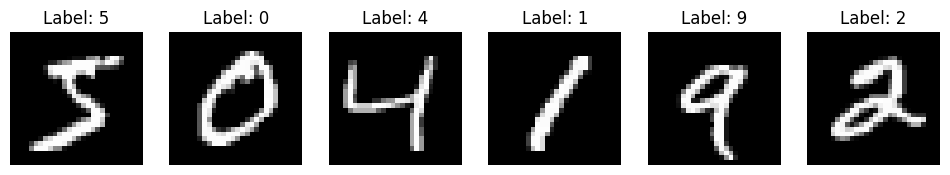

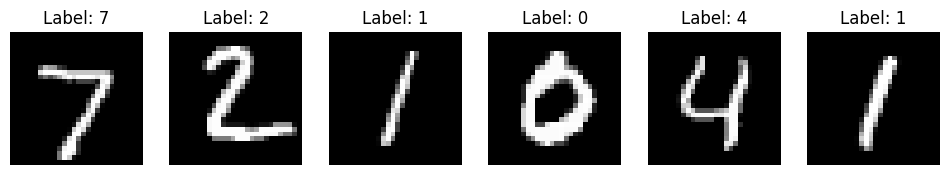

In [11]:
# show some sample images
import matplotlib.pyplot as plt

def show_images(dataset, num_images=6):
    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 2, 2))
    for i in range(num_images):
        image, label = dataset[i]
        axes[i].imshow(image.squeeze(), cmap='gray')
        axes[i].set_title(f'Label: {label}')
        axes[i].axis('off')
    plt.show()

show_images(train_dataset)
show_images(test_dataset)


In [12]:
class AutoEncoderModel(nn.Module):
    def __init__(self, input_dim=28*28, latent_dim=64):
        super(AutoEncoderModel, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed


In [13]:
# create train and test dataloaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [15]:
# train the autoencoder
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')
model = AutoEncoderModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 30

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            test_loss += loss.item() * images.size(0)
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')


Using device: cuda
Epoch [1/30], Train Loss: 0.0898, Test Loss: 0.0493
Epoch [2/30], Train Loss: 0.0444, Test Loss: 0.0392
Epoch [3/30], Train Loss: 0.0380, Test Loss: 0.0355
Epoch [4/30], Train Loss: 0.0355, Test Loss: 0.0337
Epoch [5/30], Train Loss: 0.0342, Test Loss: 0.0333
Epoch [6/30], Train Loss: 0.0334, Test Loss: 0.0326
Epoch [7/30], Train Loss: 0.0326, Test Loss: 0.0314
Epoch [8/30], Train Loss: 0.0320, Test Loss: 0.0308
Epoch [9/30], Train Loss: 0.0316, Test Loss: 0.0303
Epoch [10/30], Train Loss: 0.0309, Test Loss: 0.0297
Epoch [11/30], Train Loss: 0.0303, Test Loss: 0.0295
Epoch [12/30], Train Loss: 0.0298, Test Loss: 0.0290
Epoch [13/30], Train Loss: 0.0294, Test Loss: 0.0288
Epoch [14/30], Train Loss: 0.0290, Test Loss: 0.0282
Epoch [15/30], Train Loss: 0.0287, Test Loss: 0.0278
Epoch [16/30], Train Loss: 0.0283, Test Loss: 0.0275
Epoch [17/30], Train Loss: 0.0279, Test Loss: 0.0272
Epoch [18/30], Train Loss: 0.0276, Test Loss: 0.0269
Epoch [19/30], Train Loss: 0.0273, T

In [19]:
# show model diagram
from torchsummary import summary
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 256]         200,960
              ReLU-3                  [-1, 256]               0
            Linear-4                   [-1, 64]          16,448
            Linear-5                  [-1, 256]          16,640
              ReLU-6                  [-1, 256]               0
            Linear-7                  [-1, 784]         201,488
         Unflatten-8            [-1, 1, 28, 28]               0
Total params: 435,536
Trainable params: 435,536
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 1.66
Estimated Total Size (MB): 1.69
----------------------------------------------------------------


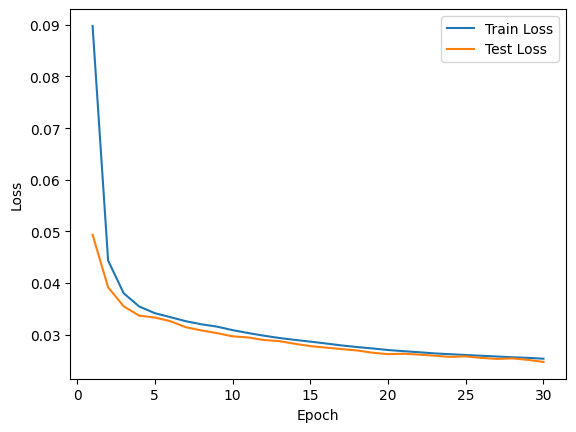

In [16]:
# plot loss curves
import matplotlib.pyplot as plt
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), test_losses, label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

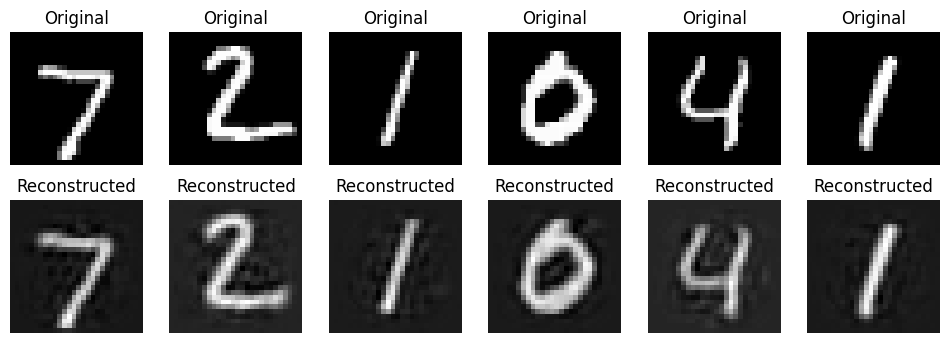

In [17]:
# visualize some reconstructed images
model.eval()
with torch.no_grad():
    sample_images, _ = next(iter(test_loader))
    sample_images = sample_images.to(device)
    reconstructed_images = model(sample_images)
    sample_images = sample_images.cpu()
    reconstructed_images = reconstructed_images.cpu()

    num_images = 6
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
    for i in range(num_images):
        axes[0, i].imshow(sample_images[i].squeeze(), cmap='gray')
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

        axes[1, i].imshow(reconstructed_images[i].squeeze(), cmap='gray')
        axes[1, i].set_title('Reconstructed')
        axes[1, i].axis('off')
    plt.show()

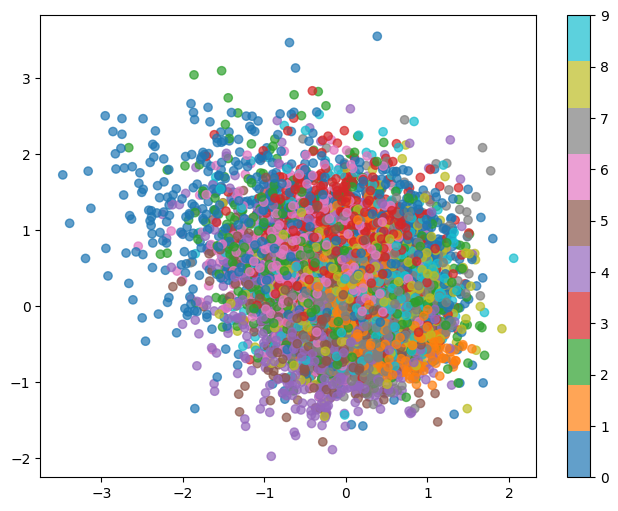

In [20]:
# plot latent space representations
import numpy as np
all_latents = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        latents = model.encoder(images)
        all_latents.append(latents.cpu().numpy())
        all_labels.append(labels.numpy())

all_latents = np.concatenate(all_latents, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(all_latents[:, 0], all_latents[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))

Text(0.5, 1.0, 'Reconstructed')

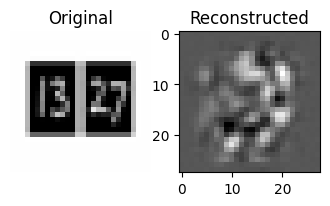

In [ ]:
from PIL import Image
image = Image.open('test_1.png').convert('L')
image = image.resize((28, 28))
image = transform(image).unsqueeze(0).to(device)
model.eval()

# let's get the reconstructed image
with torch.no_grad():
    reconstructed_image = model(image)
    reconstructed_image = reconstructed_image.cpu().squeeze().numpy()

# plot original and reconstructed images
plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(image.cpu().squeeze(), cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Reconstructed')


Text(0.5, 1.0, 'Reconstructed')

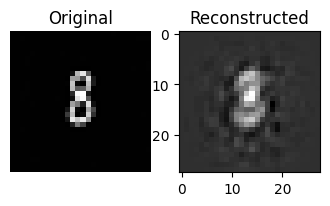

In [27]:
from PIL import Image
image = Image.open('test_4.png').convert('L')
image = image.resize((28, 28))
image = transform(image).unsqueeze(0).to(device)
model.eval()

# let's get the reconstructed image
with torch.no_grad():
    reconstructed_image = model(image)
    reconstructed_image = reconstructed_image.cpu().squeeze().numpy()

# plot original and reconstructed images
plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(image.cpu().squeeze(), cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Reconstructed')
